# Zero-shot DeepInverse RAM on the lung-MRI `.npz` exports

This notebook evaluates the pretrained **Reconstruct Anything Model (RAM)** without training or fine-tuning.

It runs two experiments:

1. **Synthetic TV8**: clean benchmark using the known synthetic degradation.
2. **Real IQT LR/HR pairs**: exploratory benchmark using the same synthetic degradation as the assumed forward operator.

This is intentionally separate from `train.ipynb`. It does not load or modify the U-Net, checkpoints, optimizer, or training code.

**Important:** the real-IQT result is exploratory because the synthetic degradation operator is not proven to be the true physical acquisition operator for the real LR scan.


In [39]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy import ndimage as ndi
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

import torch
import torch.nn.functional as F

try:
    import deepinv as dinv
except ImportError as exc:
    raise ImportError(
        "DeepInverse is not installed in this environment. "
        "Install it with: pip install deepinv"
    ) from exc

print("torch:", torch.__version__)
print("deepinv:", getattr(dinv, "__version__", "unknown"))
print("cuda available:", torch.cuda.is_available())


torch: 2.10.0+cu130
deepinv: 0.3.7
cuda available: True


In [40]:
# configuration

SEED = 0
TEST_SUBJECT = "TV8_20220307_sorted_UCL"

CROP_SIZE = 80
SCALE_FACTOR = 1.5
LR_SYNTH_SIZE = round(CROP_SIZE / SCALE_FACTOR)  # 53
SIGMA_REF = 0.6369913502160143

RAM_BATCH_SIZE = 4
TE_INDEX = 0  # TE1

torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# support both the project-root layout and Development/Outputs
output_candidates = [Path("Outputs"), Path("Development") / "Outputs"]
OUTPUT_DIR = next((p for p in output_candidates if p.exists()), output_candidates[0])

TV_EXPORT = OUTPUT_DIR / "tv_hr_crop_synthetic_lr_export.npz"

REAL_EXPORT_CANDIDATES = [
    OUTPUT_DIR / "iqt_real_pairs_export.npz",
    OUTPUT_DIR / "iqt_paired_data.npz",
]

REAL_EXPORT = next((p for p in REAL_EXPORT_CANDIDATES if p.exists()), REAL_EXPORT_CANDIDATES[0])

print("device:", device)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("TV export:", TV_EXPORT)
print("real export:", REAL_EXPORT)
print("synthetic degradation:", f"{CROP_SIZE} -> {LR_SYNTH_SIZE} -> {CROP_SIZE}")


device: cuda
OUTPUT_DIR: Outputs
TV export: Outputs\tv_hr_crop_synthetic_lr_export.npz
real export: Outputs\iqt_real_pairs_export.npz
synthetic degradation: 80 -> 53 -> 80


In [41]:
# general helpers

def require_file(path):
    if not path.exists():
        raise FileNotFoundError(
            f"Missing {path}. Run preprocessing.ipynb first or update the path above."
        )


def pick_key(npz, *candidates, required=True):
    for key in candidates:
        if key in npz.files:
            return key
    if required:
        raise KeyError(
            f"None of {candidates} found. Available keys: {list(npz.files)}"
        )
    return None


def as_str_array(values):
    values = np.asarray(values)
    if values.dtype.kind == "S":
        return np.char.decode(values, "utf-8")
    return values.astype(str)


def normalise_with_bounds(x, lo, hi):
    denom = max(float(hi) - float(lo), 1e-8)
    return np.clip((x - float(lo)) / denom, 0.0, 1.0).astype(np.float32)


def shared_lr_scale_by_group(lr, hr, groups):
    """Use LR-derived 1st/99th percentile bounds for both LR and HR."""
    lr_n = np.empty_like(lr, dtype=np.float32)
    hr_n = np.empty_like(hr, dtype=np.float32)
    bounds = {}

    for group in np.unique(groups):
        idx = groups == group
        lo = float(np.percentile(lr[idx], 1))
        hi = float(np.percentile(lr[idx], 99))
        bounds[str(group)] = (lo, hi)

        lr_n[idx] = normalise_with_bounds(lr[idx], lo, hi)
        hr_n[idx] = normalise_with_bounds(hr[idx], lo, hi)

    return lr_n, hr_n, bounds


def psnr01(pred, target):
    return peak_signal_noise_ratio(target, pred, data_range=1.0)


def ssim01(pred, target):
    return structural_similarity(target, pred, data_range=1.0)


def run_ram_batches(model, physics, measurements, batch_size=RAM_BATCH_SIZE):
    predictions = np.empty(
        (len(measurements), CROP_SIZE, CROP_SIZE),
        dtype=np.float32,
    )

    with torch.no_grad():
        for start in range(0, len(measurements), batch_size):
            end = min(start + batch_size, len(measurements))

            y = torch.from_numpy(
                measurements[start:end]
            ).float().unsqueeze(1).to(device)

            x_hat = model(y, physics)

            predictions[start:end] = (
                x_hat
                .clamp(0.0, 1.0)
                .squeeze(1)
                .cpu()
                .numpy()
                .astype(np.float32)
            )

    return predictions


def summarize_reconstruction(lr, pred, hr, extra=None):
    rows = []
    for i in range(len(hr)):
        row = {
            "index": i,
            "baseline_psnr": psnr01(lr[i], hr[i]),
            "ram_psnr": psnr01(pred[i], hr[i]),
            "baseline_ssim": ssim01(lr[i], hr[i]),
            "ram_ssim": ssim01(pred[i], hr[i]),
            "baseline_l1": float(np.mean(np.abs(lr[i] - hr[i]))),
            "ram_l1": float(np.mean(np.abs(pred[i] - hr[i]))),
        }
        if extra is not None:
            for key, values in extra.items():
                row[key] = values[i]
        rows.append(row)

    return pd.DataFrame(rows)


def show_examples(lr, pred, hr, indices, title):
    fig, axes = plt.subplots(len(indices), 3, figsize=(9, 3 * len(indices)))
    if len(indices) == 1:
        axes = np.asarray([axes])

    for row, idx in enumerate(indices):
        images = [lr[idx], pred[idx], hr[idx]]
        labels = ["LR input", "RAM zero-shot", "HR reference"]

        for col, (image, label) in enumerate(zip(images, labels)):
            axes[row, col].imshow(image, cmap="gray", vmin=0, vmax=1)
            axes[row, col].set_title(f"{label}\nframe {idx}")
            axes[row, col].axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


## Forward operator

The project degradation is represented as:

**80×80 HR → support-corrected Gaussian blur → 53×53 → resize back to 80×80.**

The support correction keeps constant images constant near the crop boundary. The operator is linear, which is required by pretrained RAM.

The adjoint below is generated with PyTorch autograd, so it is the exact adjoint of the implemented Torch operator.


In [42]:
# custom linear physics for RAM

def gaussian_kernel_2d(sigma, device, dtype):
    radius = int(4.0 * float(sigma) + 0.5)
    coords = torch.arange(
        -radius, radius + 1, device=device, dtype=dtype
    )
    kernel_1d = torch.exp(-(coords ** 2) / (2.0 * float(sigma) ** 2))
    kernel_1d = kernel_1d / kernel_1d.sum()
    kernel_2d = kernel_1d[:, None] * kernel_1d[None, :]
    return kernel_2d[None, None]


class LungIQTPhysics(dinv.physics.LinearPhysics):
    def __init__(
        self,
        sigma=SIGMA_REF,
        crop_size=CROP_SIZE,
        lr_size=LR_SYNTH_SIZE,
        device=device,
        dtype=torch.float32,
    ):
        super().__init__(
            img_size=(1, crop_size, crop_size),
            noise_model=None,
        )

        self.sigma = float(sigma)
        self.crop_size = int(crop_size)
        self.lr_size = int(lr_size)

        kernel = gaussian_kernel_2d(
            self.sigma, device=device, dtype=dtype
        )
        self.register_buffer("kernel", kernel)

        radius = kernel.shape[-1] // 2
        self.radius = int(radius)

        ones = torch.ones(
            1, 1, self.crop_size, self.crop_size,
            device=device, dtype=dtype
        )
        support = F.conv2d(ones, kernel, padding=self.radius)
        self.register_buffer("support", support)

    def A(self, x, **kwargs):
        blurred = F.conv2d(
            x,
            self.kernel.to(dtype=x.dtype),
            padding=self.radius,
        )

        blurred = (
            blurred
            / self.support.to(dtype=x.dtype).clamp_min(1e-8)
        )

        y = F.interpolate(
            blurred,
            size=(53, 53),
            mode="bicubic",
            align_corners=False,
            antialias=False,
        )

        return y

    def A_adjoint(self, y, **kwargs):
        # Exact VJP of this implemented linear operator.
        # torch.enable_grad makes this work even when RAM inference uses no_grad().
        with torch.enable_grad():
            x = torch.zeros(
                y.shape[0],
                1,
                self.crop_size,
                self.crop_size,
                device=y.device,
                dtype=y.dtype,
                requires_grad=True,
            )
            ax = self.A(x)
            (aty,) = torch.autograd.grad(
                outputs=ax,
                inputs=x,
                grad_outputs=y,
                create_graph=False,
                retain_graph=False,
            )
        return aty


physics = LungIQTPhysics().to(device)
print(physics)


LungIQTPhysics(
  (noise_model): ZeroNoise()
)


In [43]:
# validate the physics before using RAM

x_test = torch.rand(
    2, 1, CROP_SIZE, CROP_SIZE, device=device
)

with torch.no_grad():
    constant = torch.ones(
        1, 1, CROP_SIZE, CROP_SIZE, device=device
    )
    constant_out = physics.A(constant)
    constant_error = (
    constant_out - torch.ones_like(constant_out)).abs().max().item()

print("constant-preservation max error:", constant_error)
assert constant_error < 1e-4

# direct inner-product adjoint test
x_adj = torch.rand(
    2, 1, CROP_SIZE, CROP_SIZE,
    device=device,
)

y_adj = torch.rand(
    2, 1, LR_SYNTH_SIZE, LR_SYNTH_SIZE,
    device=device,
)

with torch.no_grad():
    ax = physics.A(x_adj)
    aty = physics.A_adjoint(y_adj)

lhs = torch.sum(ax * y_adj).item()
rhs = torch.sum(x_adj * aty).item()

relative_adjoint_error = (
    abs(lhs - rhs)
    / max(abs(lhs), abs(rhs), 1e-12)
)

print("adjoint relative error:", relative_adjoint_error)
assert relative_adjoint_error < 1e-5

# linearity check
a, b = 0.37, -0.22
x1 = torch.rand(1, 1, CROP_SIZE, CROP_SIZE, device=device)
x2 = torch.rand(1, 1, CROP_SIZE, CROP_SIZE, device=device)

with torch.no_grad():
    linearity_error = (
        physics.A(a * x1 + b * x2)
        - (a * physics.A(x1) + b * physics.A(x2))
    ).abs().max().item()

print("linearity max error:", linearity_error)
assert linearity_error < 1e-5

print("Physics validation passed.")


constant-preservation max error: 4.76837158203125e-07
adjoint relative error: 8.699051611995157e-08
linearity max error: 1.341104507446289e-07
Physics validation passed.


In [44]:
# load pretrained RAM, no training or fine-tuning

model = dinv.models.RAM(
    pretrained=True,
    device=device,
).eval()

print("Loaded pretrained RAM.")


Loaded pretrained RAM.


## Synthetic TV8 zero-shot benchmark

In [45]:
# load TV export and select the held-out TV8 subject

require_file(TV_EXPORT)

tv = np.load(TV_EXPORT, allow_pickle=True)
print("TV export keys:", list(tv.files))

hr_key = pick_key(tv, "hr_frames", "hr_crops")
subject_key = pick_key(tv, "subject", "subjects")
slice_key = pick_key(tv, "slice", "slices")
included_key = pick_key(tv, "included", required=False)
dynamic_key = pick_key(tv, "dynamic", "dynamics", required=False)

hr_all = np.asarray(tv[hr_key], dtype=np.float32)
subjects_all = as_str_array(tv[subject_key])
slices_all = np.asarray(tv[slice_key]).astype(int)

if included_key is None:
    included_all = np.ones(len(hr_all), dtype=bool)
else:
    included_all = np.asarray(tv[included_key]).astype(bool)

if dynamic_key is None:
    dynamics_all = np.arange(len(hr_all))
else:
    dynamics_all = np.asarray(tv[dynamic_key])

assert len(hr_all) == len(subjects_all) == len(slices_all) == len(included_all)

test_mask = included_all & (subjects_all == TEST_SUBJECT)

hr_raw = hr_all[test_mask]
test_slices = slices_all[test_mask]
test_dynamics = dynamics_all[test_mask]

if hr_raw.ndim == 4 and hr_raw.shape[1] == 1:
    hr_raw = hr_raw[:, 0]

assert len(hr_raw) > 0, f"No included frames found for {TEST_SUBJECT}"
assert hr_raw.shape[-2:] == (CROP_SIZE, CROP_SIZE)

print("TV8 frames:", len(hr_raw))
print("TV8 HR shape:", hr_raw.shape)
print("TV8 slices:", np.unique(test_slices))


TV export keys: ['hr_frames', 'lr_synth_frames', 'subject', 'slice', 'dynamic', 'phase_bin', 'phase_direction', 'anchor_row', 'anchor_col', 'crop_origin_row', 'crop_origin_col', 'included']
TV8 frames: 1140
TV8 HR shape: (1140, 80, 80)
TV8 slices: [1 2 3 4 5 6]


In [46]:
def apply_physics_numpy(frames, batch_size=32):
    out = np.empty(
        (len(frames), LR_SYNTH_SIZE, LR_SYNTH_SIZE),
        dtype=np.float32,
    )

    with torch.no_grad():
        for start in range(0, len(frames), batch_size):
            end = min(start + batch_size, len(frames))

            x = torch.from_numpy(
                frames[start:end]
            ).float().unsqueeze(1).to(device)

            out[start:end] = (
                physics.A(x)
                .squeeze(1)
                .cpu()
                .numpy()
                .astype(np.float32)
            )

    return out


lr_raw = apply_physics_numpy(hr_raw)

print("HR:", hr_raw.shape)
print("LR measurement:", lr_raw.shape)


lr_raw = apply_physics_numpy(hr_raw)

# same LR-derived percentile scale for LR and HR, per slice
lr_norm, hr_norm, tv8_bounds = shared_lr_scale_by_group(
    lr_raw,
    hr_raw,
    test_slices,
)

print("LR range:", float(lr_norm.min()), float(lr_norm.max()))
print("HR range:", float(hr_norm.min()), float(hr_norm.max()))

# quantify the small inconsistency introduced by clipping normalised HR
with torch.no_grad():
    hr_t = torch.from_numpy(hr_norm).float().unsqueeze(1).to(device)
    lr_from_hr_norm = (
        physics.A(hr_t).squeeze(1).cpu().numpy()
    )

measurement_consistency_mae = float(
    np.mean(np.abs(lr_from_hr_norm - lr_norm))
)

print(
    "mean |A(clipped HR_norm) - LR_norm|:",
    measurement_consistency_mae,
)

if measurement_consistency_mae > 0.01:
    warnings.warn(
        "Normalisation/clipping creates a noticeable forward-model mismatch. "
        "Interpret RAM results cautiously."
    )


HR: (1140, 80, 80)
LR measurement: (1140, 53, 53)
LR range: 0.0 1.0
HR range: 4.254758096067235e-05 1.0
mean |A(clipped HR_norm) - LR_norm|: 0.0011485483264550567


In [47]:
# zero-shot RAM inference on TV8

ram_tv8 = run_ram_batches(
    model,
    physics,
    lr_norm,
)
def resize_lr_baseline(lr):
    x = torch.from_numpy(
        lr
    ).float().unsqueeze(1).to(device)

    with torch.no_grad():
        x = F.interpolate(
            x,
            size=(CROP_SIZE, CROP_SIZE),
            mode="bicubic",
            align_corners=False,
            antialias=False,
        )

    return (
        x.clamp(0.0, 1.0)
        .squeeze(1)
        .cpu()
        .numpy()
        .astype(np.float32)
    )


lr_baseline = resize_lr_baseline(lr_norm)

print("RAM input:", lr_norm.shape)
print("LR baseline:", lr_baseline.shape)
print("RAM output:", ram_tv8.shape)
print("HR:", hr_norm.shape)

tv8_df = summarize_reconstruction(
    lr_baseline,
    ram_tv8,
    hr_norm,
    extra={
        "slice": test_slices,
        "dynamic": test_dynamics,
    },
)

tv8_summary = pd.Series({
    "n_frames": len(tv8_df),
    "baseline_psnr": tv8_df["baseline_psnr"].mean(),
    "ram_psnr": tv8_df["ram_psnr"].mean(),
    "psnr_delta": tv8_df["ram_psnr"].mean() - tv8_df["baseline_psnr"].mean(),
    "baseline_ssim": tv8_df["baseline_ssim"].mean(),
    "ram_ssim": tv8_df["ram_ssim"].mean(),
    "ssim_delta": tv8_df["ram_ssim"].mean() - tv8_df["baseline_ssim"].mean(),
    "baseline_l1": tv8_df["baseline_l1"].mean(),
    "ram_l1": tv8_df["ram_l1"].mean(),
})

print("Synthetic TV8 summary")
display(tv8_summary.to_frame("value"))

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

tv8_df.to_csv(
    OUTPUT_DIR / "eval_synthetic_tv8_ram_zero_shot.csv",
    index=False,
)

np.savez_compressed(
    OUTPUT_DIR / "ram_zero_shot_tv8_outputs.npz",
    prediction=ram_tv8,
    lr=lr_norm,
    hr=hr_norm,
    slice=test_slices,
    dynamic=test_dynamics,
    subject=np.full(len(ram_tv8), TEST_SUBJECT),
    sigma_ref=np.array(SIGMA_REF, dtype=np.float32),
    scale_factor=np.array(SCALE_FACTOR, dtype=np.float32),
    lr_synth_size=np.array(LR_SYNTH_SIZE, dtype=np.int32),
    model=np.array("DeepInverse RAM pretrained zero-shot"),
)

print("Saved synthetic RAM results to:", OUTPUT_DIR)


RAM input: (1140, 53, 53)
LR baseline: (1140, 80, 80)
RAM output: (1140, 80, 80)
HR: (1140, 80, 80)
Synthetic TV8 summary


,value
n_frames,1140.000000
baseline_psnr,27.263784
ram_psnr,29.262352
psnr_delta,1.998567
baseline_ssim,0.939163
ram_ssim,0.957128
ssim_delta,0.017965
baseline_l1,0.026842
ram_l1,0.021679


Saved synthetic RAM results to: Outputs


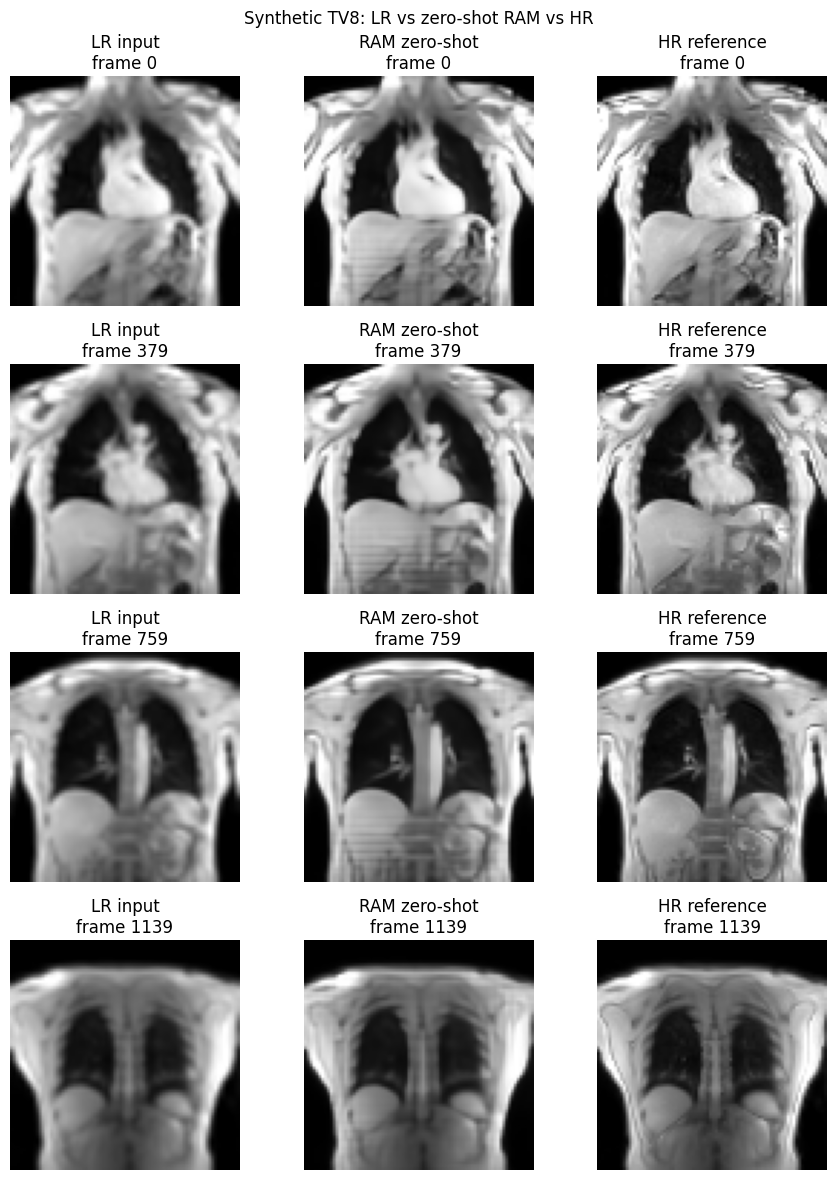

In [48]:
# qualitative TV8 examples

n_show = min(4, len(hr_norm))
example_indices = np.linspace(
    0, len(hr_norm) - 1, n_show, dtype=int
).tolist()

show_examples(
    lr_baseline,
    ram_tv8,
    hr_norm,
    example_indices,
    "Synthetic TV8: LR vs zero-shot RAM vs HR",
)


## Real IQT exploratory benchmark

The native real LR frames are first resampled from **64×64 to 96×96**, then the same **80×80 HR-space crop** is taken. This preserves the established real-IQT evaluation geometry.

The same LR-derived percentile scale is applied to LR and HR for each slice. This matters because RAM output lives in the normalised LR input scale.

RAM is still given the synthetic `LungIQTPhysics` operator. Therefore this result tests transfer under an **assumed** forward model, not exact physical data consistency with the real acquisition.


In [59]:
# load and prepare the real IQT LR/HR pairs

require_file(REAL_EXPORT)

real = np.load(
    REAL_EXPORT,
    allow_pickle=True,
)

print("real export keys:", list(real.files))

real_lr_crop = np.asarray(
    real["lr_frames"],
    dtype=np.float32,
)

real_hr_crop = np.asarray(
    real["hr_frames"],
    dtype=np.float32,
)

assert real_lr_crop.ndim == 3
assert real_hr_crop.ndim == 3

assert real_lr_crop.shape == real_hr_crop.shape
assert real_lr_crop.shape[-2:] == (CROP_SIZE, CROP_SIZE)

print("real LR:", real_lr_crop.shape)
print("real HR:", real_hr_crop.shape)

print(
    "recorded native LR size:",
    np.unique(real["lr_native_size"]),
)

print(
    "recorded native HR size:",
    np.unique(real["hr_native_size"]),
)

real export keys: ['lr_frames', 'hr_frames', 'slice', 'lr_dynamic', 'hr_dynamic', 'echo', 'phase_bin', 'direction', 'fallback', 'phase_pairing_distance', 'mean_dice', 'n_slices_scored', 'anchor_row', 'anchor_col', 'crop_origin_row', 'crop_origin_col', 'landmark_diaphragm_y', 'landmark_mid_x', 'lr_native_size', 'hr_native_size', 'included', 'exclusion_reason']
real LR: (180, 80, 80)
real HR: (180, 80, 80)
recorded native LR size: [64]
recorded native HR size: [96]


In [60]:
# real IQT export already stores aligned/cropped 80x80 LR/HR pairs

real_lr_crop = np.asarray(
    real["lr_frames"],
    dtype=np.float32,
)

real_hr_crop = np.asarray(
    real["hr_frames"],
    dtype=np.float32,
)

real_slice = np.asarray(
    real["slice"]
).astype(int)

real_pair = np.arange(
    len(real_lr_crop)
)

assert real_lr_crop.ndim == 3
assert real_hr_crop.ndim == 3

assert real_lr_crop.shape == real_hr_crop.shape
assert real_lr_crop.shape[-2:] == (CROP_SIZE, CROP_SIZE)

assert len(real_slice) == len(real_lr_crop)
assert len(real_pair) == len(real_lr_crop)

# keep only included pairs if the export contains an inclusion flag
if "included" in real.files:
    included = np.asarray(
        real["included"]
    ).astype(bool)

    assert len(included) == len(real_lr_crop)

    real_lr_crop = real_lr_crop[included]
    real_hr_crop = real_hr_crop[included]
    real_slice = real_slice[included]
    real_pair = real_pair[included]

print("prepared real LR:", real_lr_crop.shape)
print("prepared real HR:", real_hr_crop.shape)
print("real slices:", np.unique(real_slice))
print("included pairs:", len(real_lr_crop))

prepared real LR: (180, 80, 80)
prepared real HR: (180, 80, 80)
real slices: [1 2 3 4 5 6]
included pairs: 180


In [61]:
real_lr_norm, real_hr_norm, real_bounds = shared_lr_scale_by_group(
    real_lr_crop,
    real_hr_crop,
    real_slice,
)

print(
    "real LR range:",
    float(real_lr_norm.min()),
    float(real_lr_norm.max()),
)

print(
    "real HR range:",
    float(real_hr_norm.min()),
    float(real_hr_norm.max()),
)

real LR range: 0.0 1.0
real HR range: 0.0 1.0


In [63]:
# zero-shot RAM inference on real IQT
#
# IMPORTANT:
# the real export contains 80x80 processed LR images, while the RAM physics
# now expects a 53x53 measurement. For this exploratory real-data test,
# resize the real LR to 53x53 before passing it to RAM.
#
# real_lr_norm remains unchanged as the 80x80 baseline for evaluation.

def resize_real_lr_to_measurement(lr):
    x = torch.from_numpy(
        lr
    ).float().unsqueeze(1).to(device)

    with torch.no_grad():
        y = F.interpolate(
            x,
            size=(LR_SYNTH_SIZE, LR_SYNTH_SIZE),
            mode="bicubic",
            align_corners=False,
            antialias=False,
        )

    return (
        y.squeeze(1)
        .cpu()
        .numpy()
        .astype(np.float32)
    )


real_measurement = resize_real_lr_to_measurement(
    real_lr_norm
)

print("real LR baseline:", real_lr_norm.shape)
print("RAM measurement:", real_measurement.shape)
print("real HR:", real_hr_norm.shape)

assert real_lr_norm.shape[-2:] == (CROP_SIZE, CROP_SIZE)
assert real_measurement.shape[-2:] == (
    LR_SYNTH_SIZE,
    LR_SYNTH_SIZE,
)
assert real_hr_norm.shape[-2:] == (CROP_SIZE, CROP_SIZE)


# RAM receives the 53x53 measurement
ram_real = run_ram_batches(
    model,
    physics,
    real_measurement,
)


# metadata
extra = {
    "pair": real_pair,
    "slice": real_slice,
}

real_lr_dynamic = None
real_hr_dynamic = None

if "lr_dynamic" in real.files:
    real_lr_dynamic = np.asarray(
        real["lr_dynamic"]
    )

if "hr_dynamic" in real.files:
    real_hr_dynamic = np.asarray(
        real["hr_dynamic"]
    )

if "included" in real.files:
    if real_lr_dynamic is not None:
        real_lr_dynamic = real_lr_dynamic[included]

    if real_hr_dynamic is not None:
        real_hr_dynamic = real_hr_dynamic[included]

if real_lr_dynamic is not None:
    extra["lr_dynamic"] = real_lr_dynamic

if real_hr_dynamic is not None:
    extra["hr_dynamic"] = real_hr_dynamic


# compare:
#   80x80 real LR baseline
#   80x80 RAM reconstruction
#   80x80 real HR reference
real_df = summarize_reconstruction(
    real_lr_norm,
    ram_real,
    real_hr_norm,
    extra=extra,
)


real_summary = pd.Series({
    "n_frames": len(real_df),

    "baseline_psnr": real_df[
        "baseline_psnr"
    ].mean(),

    "ram_psnr": real_df[
        "ram_psnr"
    ].mean(),

    "psnr_delta": (
        real_df["ram_psnr"].mean()
        - real_df["baseline_psnr"].mean()
    ),

    "baseline_ssim": real_df[
        "baseline_ssim"
    ].mean(),

    "ram_ssim": real_df[
        "ram_ssim"
    ].mean(),

    "ssim_delta": (
        real_df["ram_ssim"].mean()
        - real_df["baseline_ssim"].mean()
    ),

    "baseline_l1": real_df[
        "baseline_l1"
    ].mean(),

    "ram_l1": real_df[
        "ram_l1"
    ].mean(),
})


print("Real IQT summary (exploratory)")
display(
    real_summary.to_frame("value")
)


real_df.to_csv(
    OUTPUT_DIR
    / "eval_real_iqt_ram_zero_shot.csv",
    index=False,
)


np.savez_compressed(
    OUTPUT_DIR
    / "ram_zero_shot_real_iqt_outputs.npz",

    prediction=ram_real,

    # 80x80 existing LR used for baseline metrics
    lr=real_lr_norm,

    # 53x53 input actually supplied to RAM
    ram_measurement=real_measurement,

    hr=real_hr_norm,

    pair=real_pair,
    slice=real_slice,

    sigma_ref=np.array(
        SIGMA_REF,
        dtype=np.float32,
    ),

    scale_factor=np.array(
        SCALE_FACTOR,
        dtype=np.float32,
    ),

    lr_synth_size=np.array(
        LR_SYNTH_SIZE,
        dtype=np.int32,
    ),

    model=np.array(
        "DeepInverse RAM pretrained zero-shot"
    ),

    physics_note=np.array(
        "Exploratory real-IQT test. "
        "The exported 80x80 real LR image was resized to 53x53 "
        "for input to RAM. RAM was supplied the synthetic "
        "blur+downsampling forward model, which is not known "
        "to represent the true real MRI acquisition."
    ),
)


print(
    "Saved real-IQT RAM results to:",
    OUTPUT_DIR,
)

real LR baseline: (180, 80, 80)
RAM measurement: (180, 53, 53)
real HR: (180, 80, 80)
Real IQT summary (exploratory)


,value
n_frames,180.000000
baseline_psnr,18.728918
ram_psnr,18.489461
psnr_delta,-0.239457
baseline_ssim,0.688129
ram_ssim,0.675870
ssim_delta,-0.012259
baseline_l1,0.087621
ram_l1,0.087620


Saved real-IQT RAM results to: Outputs


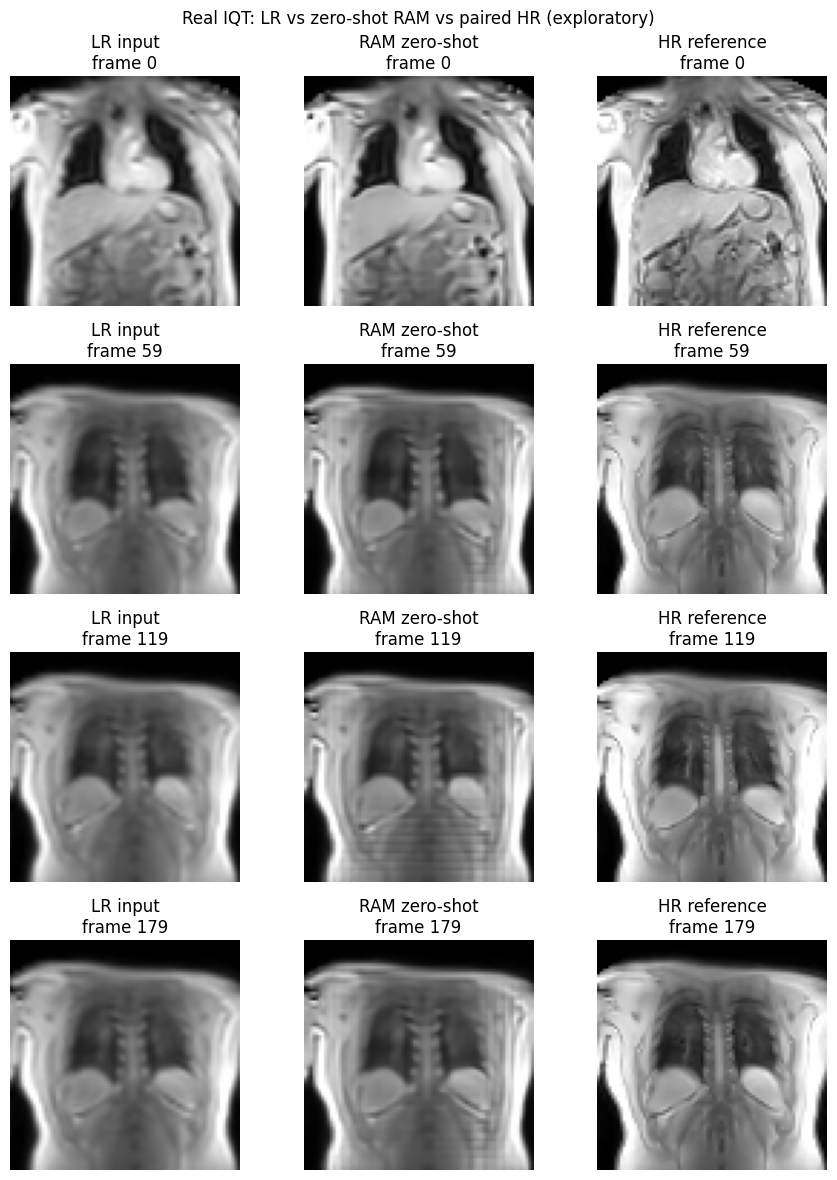

In [64]:
# qualitative real-IQT examples

n_show = min(4, len(real_hr_norm))
example_indices = np.linspace(
    0, len(real_hr_norm) - 1, n_show, dtype=int
).tolist()

show_examples(
    real_lr_norm,
    ram_real,
    real_hr_norm,
    example_indices,
    "Real IQT: LR vs zero-shot RAM vs paired HR (exploratory)",
)


## Interpretation

Use the synthetic TV8 result as the clean zero-shot benchmark.

For the real IQT result:

- do **not** claim that RAM enforces the true MRI acquisition physics;
- the LR/HR scans come from different acquisitions and have a known contrast/domain mismatch;
- the synthetic forward operator is only an assumed approximation on this dataset.

A fair dissertation description is therefore:

> A pretrained RAM model was evaluated zero-shot using the synthetic blur/downsampling operator as the supplied linear forward model. Performance was measured on the held-out synthetic subject and, separately, explored on paired real IQT acquisitions to assess cross-domain transfer.
